Author(s) : Laura Gómez Navarro, Daniel R. Tarry, ...

Objective: Describe xxx

Created on: March 2023


In [1]:
import time

print('Last update:', time.ctime(time.time()))

Last update: Thu Apr  4 17:09:45 2024


# To improve:
* improve day selection (not with the logical)
* cmocean colorbar?
* colorbar last subplot using gridspec!
* clean SVP data
* Update TOC    

<a id="0"></a> <br>
# Table of Contents  
1. [Loading the data](#1)     
    1. [Drifters](#1.1.) 
        1. [SVP-B](#1.1.1.) 
        2. [CARTHE](#1.1.2.) 
        3. [HEREON](#1.1.3.) 
    2. [Daily satellite field (SST)](#1.2.) 
    3. [SWOT and transects](#1.3.) 
2. [Plotting all trajectories](#2)
    1. [SVP-B drifters](#2.1.)
        1. [Full trajectories (zoom)](#2.1.1.)
        2. [Full trajectories (full map extent)](#2.1.2.)
        3. [Full trajectories (traj. extent)](#2.1.3.)
    2. [CARTHE](#2.2.)
        1. [Full trajectories (regional zoom)](#2.2.1.)
        2. [Full trajectories (full map extent)](#2.2.2.)
        3. [Full trajectories (traj. extent)](#2.2.3.)
        4. [Only trajectory on day 15/05/23 (+/- 1 day)](#2.2.4.)
        5. [Full trajectories (regional zoom) + Highlight of trajectory on day 15/05/23 (+/- 1 day)](#2.2.5.)
    3. [HEREON](#2.3.)
        1. [Full trajectories (regional zoom)](#2.3.1.)
        2. [Full trajectories (full map extent)](#2.3.2.)
        3. [Full trajectories (traj. extent)](#2.3.3.)
        4. [Only trajectory on day 15/05/23 (+/- 1 day)](#2.3.4.)
        5. [Full trajectories (regional zoom) + Highlight of trajectory on day 15/05/23 (+/- 1 day)](#2.3.5.)
        6. [Extra](#2.3.6.)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature       as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
# LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import xarray as xr
# import cf_xarray
# import folium
# import seawater as sw
# from palettable import cmocean
import cmocean
import datetime
import json
# from erddapy import ERDDAP
import matplotlib.colors as colors
import netCDF4               as netcdf
import matplotlib.gridspec   as gridspec


<a id="1"></a> 
# 1. Loading the data:

### L1 clean data:

In [12]:
!ls ../../../data/drifters/L1_IMEDEA 

dep0001_drifter-svpb039_ime-svpb039_L1_2023-04-26.nc
drifter-svpb035.nc
drifter-svpb038.nc
drifter-svpb039.nc
drifter-svpb040.nc
drifter-svpb041.nc
drifter-svpb042.nc
drifter_carthe006-ime_carthe001.nc
drifter_carthe007-ime_carthe002.nc
drifter_carthe008-ime_carthe003.nc
drifter_carthe009-ime_carthe004.nc
drifter_carthe010-ime_carthe005.nc
drifter_carthe011-ime_carthe006.nc
drifter_carthe012-ime_carthe007.nc
drifter_carthe013-ime_carthe008.nc
drifter_carthe014-ime_carthe009.nc
drifter_carthe015-ime_carthe010.nc
drifter_carthe016-ime_carthe011.nc
drifter_carthe017-ime_carthe012.nc
drifter_carthe018-ime_carthe013.nc
drifter_carthe019-ime_carthe014.nc
drifter_carthe020-ime_carthe015.nc
drifter_carthe021-ime_carthe016.nc
drifter_carthe022-ime_carthe017.nc
drifter_carthe023-ime_carthe018.nc
drifter_carthe024-ime_carthe019.nc
drifter_carthe025-ime_carthe020.nc
drifter_hereon001-ime_hereon001.nc
drifter_hereon002-ime_hereon002.nc
drifter_hereon003-ime_hereon003.nc
drifter_hereon004-ime_hereon

In [11]:

filedir = "../../../data/drifters/L1_IMEDEA/"

<a id="1.1."></a> 
## 1.1. Drifters

<a id="1.1.1."></a> 
### 1.1.1. SVP-B

In [16]:
#42: 26/04
drifter_num = '42'.zfill(3)
url_01 = filedir + "drifter-svpb" + drifter_num + ".nc"
ds_svp042 = xr.open_dataset(url_01)

#41: 26/04
drifter_num = '41'.zfill(3)
url_01 = filedir + "drifter-svpb" + drifter_num + ".nc"
ds_svp041 = xr.open_dataset(url_01)

#40: 26/04
drifter_num = '40'.zfill(3)
url_01 = filedir + "drifter-svpb" + drifter_num + ".nc"
ds_svp040 = xr.open_dataset(url_01)

#39: 26/04
drifter_num = '39'.zfill(3)
url_01 = filedir + "drifter-svpb" + drifter_num + ".nc"
ds_svp039 = xr.open_dataset(url_01)

# #38: 26/04
drifter_num = '38'.zfill(3)
url_01 = filedir + "drifter-svpb" + drifter_num + ".nc"
ds_svp038 = xr.open_dataset(url_01)



### THE SVP-B drifter of Leg 1 (previous to launch), the cool one in the eddy:
<br>
Surface drifter SCB-SVPB035 (wmo 6102812)
<br>

http://apps.socib.es/dapp/?deployments=2142-30-0

In [14]:
#35: 23/02
drifter_num = '35'.zfill(3)
url_01 = filedir + "drifter-svpb" + drifter_num + ".nc"
ds_svp035 = xr.open_dataset(url_01)

In [15]:
ds_svp_leg1 = [ds_svp035, ds_svp038, ds_svp039
                        ,ds_svp040, ds_svp041, ds_svp042]

### THE SVP-B drifter of Leg 1 (previous to launch), the cool one in the eddy:
<br>
Surface drifter SCB-SVPB035 (wmo 6102812)
<br>

http://apps.socib.es/dapp/?deployments=2142-30-0

In [9]:
url_01 = url_root + "drifter_svpb035-scb_svpb035/L1/2023/dep0001_drifter-svpb035_scb-svpb035_L1_2023-02-20.nc?" + url_vars_svp
ds_svp035 = xr.open_dataset(url_01)

In [17]:
ds_svp_leg1 = [ds_svp035, ds_svp038, ds_svp039
                        ,ds_svp040, ds_svp041, ds_svp042]

In [18]:
svp_leg1_n = ['svp035', 'svp038', 'svp039'
                        ,'svp040', 'svp041', 'svp042']

<a id="1.1.2."></a> 
### 1.1.2. CARTHE

In [20]:
!ls ../../../data/drifters/L1_IMEDEA/*carthe*

../../../data/drifters/L1_IMEDEA/drifter_carthe006-ime_carthe001.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe007-ime_carthe002.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe008-ime_carthe003.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe009-ime_carthe004.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe010-ime_carthe005.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe011-ime_carthe006.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe012-ime_carthe007.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe013-ime_carthe008.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe014-ime_carthe009.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe015-ime_carthe010.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe016-ime_carthe011.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe017-ime_carthe012.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe018-ime_carthe013.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe019-ime_carthe014.nc
../../../data/drifters/L1_IMEDEA/drifter_carthe0

In [21]:
ds_car010 = xr.open_dataset(filedir + 'drifter_carthe015-ime_carthe010.nc') #*_carthe010.nc --> does not work with *
ds_car010

<xarray.Dataset>
Dimensions:     (time: 266)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-28T01:10:00 ... 2023-04-29T21:2...
Data variables:
    DEPTH       (time) float64 ...
    BAT_STATUS  (time) float64 ...
    LAT         (time) float64 ...
    LON         (time) float64 ...
    U           (time) float64 ...
    V           (time) float64 ...
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE010 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE010 in FaSt-...
    summary:                             Deployment of IME-CARTHE010 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [22]:
mm = '4'.zfill(2)

#8: 27/04
drifter_num = '8'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car008 = xr.open_dataset(url_01)

#07: 27/04
drifter_num = '7'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car007 = xr.open_dataset(url_01)

#06: 27/04
drifter_num = '6'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car006 = xr.open_dataset(url_01)

#05: 27/04
drifter_num = '5'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car005 = xr.open_dataset(url_01)

#04: 27/04
drifter_num = '4'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car004 = xr.open_dataset(url_01)

#03: 26/04
drifter_num = '3'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car003 = xr.open_dataset(url_01)

#02: 26/04
drifter_num = '2'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car002 = xr.open_dataset(url_01)

#01: 26/04
drifter_num = '1'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car001 = xr.open_dataset(url_01)

#09: 24/04
drifter_num = '9'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car009 = xr.open_dataset(url_01)



In [23]:
ds_car_leg1 = [ds_car001, ds_car002, ds_car003
                        , ds_car004, ds_car005, ds_car006, ds_car007, ds_car008 
                       , ds_car009
               , ds_car010]

In [24]:
car_leg1_n = ['car001', 'car002', 'car003'
                ,'car004', 'car005', 'car006', 'car007', 'car008' 
                ,'car009', 'car010']

<a id="1.1.3."></a> 
### 1.1.3. HEREON:

In [26]:
!ls ../../../data/drifters/L1_IMEDEA/*hereon*

../../../data/drifters/L1_IMEDEA/drifter_hereon001-ime_hereon001.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon002-ime_hereon002.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon003-ime_hereon003.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon004-ime_hereon004.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon005-ime_hereon005.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon006-ime_hereon006.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon007-ime_hereon007.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon008-ime_hereon008.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon009-ime_hereon009.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon010-ime_hereon010.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon011-ime_hereon011.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon012-ime_hereon012.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon013-ime_hereon013.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon014-ime_hereon014.nc
../../../data/drifters/L1_IMEDEA/drifter_hereon0

In [27]:
url_01 = filedir + "drifter_hereon011-ime_hereon011.nc" 
ds_her011 = xr.open_dataset(url_01)

In [28]:
mm = '4'.zfill(2)

#10: 28/04
drifter_num = '10'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her010 = xr.open_dataset(url_01)

#09: 27/04
drifter_num = '9'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her009 = xr.open_dataset(url_01)

#08: 27/04
drifter_num = '8'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her008 = xr.open_dataset(url_01)

#07: 27/04
drifter_num = '7'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her007 = xr.open_dataset(url_01)

#06: 27/04
drifter_num = '6'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her006 = xr.open_dataset(url_01)

#04: 27/04
drifter_num = '4'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her004 = xr.open_dataset(url_01)

#03: 26/04
drifter_num = '3'.zfill(3)
dd = '26'.zfill(2)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her003 = xr.open_dataset(url_01)

#02: 26/04
drifter_num = '2'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her002 = xr.open_dataset(url_01)

#01: 26/04
drifter_num = '1'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her001 = xr.open_dataset(url_01)

In [29]:
ds_her_leg1 = [ds_her001, ds_her002, ds_her003
                        ,ds_her004, ds_her006, ds_her007, ds_her008
                        ,ds_her009, ds_her010, ds_her011]

In [30]:
her_leg1_n = ['her001', 'her002', 'her003'
                        ,'her004', 'her006'
              , 'her007', 'her008'
                        ,'her009', 'her010', 'her011']

<a id="1.2."></a> 
## 1.2. Daily satellite field (SST)
(Barbara plot). SST here:

In [36]:
# !ls /Users/Gomez023/Postdoc/develop/FaSt-SWOT/*nc
#filedir = '/Users/Gomez023/Postdoc/develop/FaSt-SWOT/'

In [34]:
# ds_sst = xr.open_dataset(filedir + 'dSST_last_6d_sub.nc') # 11 to 16 May
# ds_sst = xr.open_dataset(filedir + 'SST_last_6d_sub.nc') # 04 to 09 Nov 2023
# ds_sst = xr.open_dataset(filedir + 'dSST_last_6d_sub_230507_230512.nc')  # 7 to 12 May 2023
# ds_sst = xr.open_dataset(filedir + 'ds_CHL_last_6d_sub.nc') # 10 to 15 may
ds_sst = xr.open_dataset('../../../data/20230426000000-GOS-L3S_GHRSST-SSTsubskin-night_SST_UHR_NRT-MED-v02.0-fv01.0.nc')


In [37]:
ds_sst.time

<xarray.DataArray 'time' (time: 1)>
array(['2023-04-26T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2023-04-26
Attributes:
    long_name:            reference time of sst field
    standard_name:        time
    axis:                 T
    comment:              Nominal time of Level 4 analysis
    _CoordinateAxisType:  Time

<a id="1.3."></a> 
## 1.3. SWOT and transects

In [44]:
filedir = '../../../data/'

In [45]:
transect = np.load(filedir + 'FaSt-SWOT2_transect.npz')
#http://localhost:8888/notebooks/FaSt-SWOT/FaST-SWOT2_SST_map_radiator_grid_MVP_CTD_and_gliders_along_swath_edited.ipynb
lon_south=transect['lon_south']
lon_north=transect['lon_north']
lat_south=transect['lat_south']
lat_north=transect['lat_north']

# lon_north=lon_east, lat_south=lat_west, lat_north=lat_east

In [46]:
dir_swaths = filedir
    
file_swaths1 = 'MED_fastPhase_1km_swotFAST_grid_p009.nc'
file_swaths2 = 'MED_fastPhase_1km_swotFAST_grid_p022.nc'

nc    = netcdf.Dataset(dir_swaths + file_swaths1, 'r')
latsw1  = nc.variables['lat'][:]   
lonsw1  = nc.variables['lon'][:]  
x_ac1   = nc.variables['x_ac'][:]  # "Across track distance from nadir"

lonnd1  = nc.variables['lon_nadir'][:] 
latnd1  = nc.variables['lat_nadir'][:] 
nc.close()     

nc    = netcdf.Dataset(dir_swaths + file_swaths2, 'r')
latsw2  = nc.variables['lat'][:]   
lonsw2  = nc.variables['lon'][:]  
x_ac2   = nc.variables['x_ac'][:]  # "Across track distance from nadir"

lonnd2  = nc.variables['lon_nadir'][:] 
latnd2  = nc.variables['lat_nadir'][:]     

nc.close()  

In [47]:
ds_sst.time[-1].data

array('2023-04-26T00:00:00.000000000', dtype='datetime64[ns]')

<a id="2"></a> <br>
# 2. Plotting all trajectories:

In [52]:
!ls ../../../../

2024b_DC_SWOTdenoising
2024b_DC_SWOTdenoising_old
Blue-Cloud-Sea-Clearly
Cosas_noe.ipynb
ESA_WOC
EddyAccumulation
FaSt-SWOT
Lagrangian_diags
Master-Thesis
Menextract2pdf
OceanParcels_Lyapunov
SWOT-OpenToolkit
SWOT-TOC
SWOTmodule
SWOTmodule-LGN
Sargassum_Drifters
WOC_OilSpills
adriftOpenLayers
fast_swot_drifter_processing_rough.ipynb
oceanparcels_website
parcels_contributions
parcels_gallery
planets
powerspec
py-eddy-tracker
repo_prueba
swot_simulator
tutoriales


In [70]:
rootdir = "/Users/Gomez023/Library/CloudStorage/" #"/Users/Gomez023/Library/CloudStorage/"

In [71]:
savefigdir = rootdir + "OneDrive-UniversitatdelesIllesBalears/Data/FaSt-SWOT/Figures/"

In [72]:
def FaSt_SWOT_features(axn, aan, dsn, gs_xn, gs_yn, field=True, sub_uneq=0, map_extent=[.7, 3.0, 38.9, 40.5]):
    """
    axn = axis handle
    dsn = xarray drifter dataset
    field = True or false, if you want to show the SST or Chl. field in the background
    """
    
    axn.set_extent(map_extent, crs=ccrs.PlateCarree())

    # Font and markersizes:
    msize=1
    fsize=14
    
    
    # SWOT swaths
    axn.scatter(lonsw1.flatten(), latsw1.flatten(), c='lavender', s=msize/25, zorder=2, alpha=.5,
                    transform=ccrs.PlateCarree())
    axn.scatter(lonsw2.flatten(), latsw2.flatten(), c='lavender', s=msize/25, zorder=2, alpha=.5,
                    transform=ccrs.PlateCarree())
    axn.scatter(lonnd1.flatten(), latnd1.flatten(), c='lavender', s=msize/25, zorder=2, alpha=.5,
                    transform=ccrs.PlateCarree())
    axn.scatter(lonnd2.flatten(), latnd2.flatten(), c='lavender', s=msize/25, zorder=2, alpha=.5, label='SWOT',
                    transform=ccrs.PlateCarree())

    #Land
    feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                                  scale='10m', zorder=10,
                                                  edgecolor='black', facecolor='#AAAAAA')
    axn.add_feature(feature)

    # Grid and ticks
    gl = axn.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

    gl.top_labels = False
    gl.left_labels = False
    gl.right_labels = False
    if aan < ((gs_y * (gs_x-2)) - sub_uneq): # for horizontal cbar at bottom * (gs_x-1)):
        gl.bottom_labels = False
    if ((aan == 0) | (aan % gs_y == 0)) & (aan < gs_y * (gs_x-1)):  # last and is only valid if colorbar in bottom row
        gl.left_labels = True
    
    gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
    gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}
  
    # Title
    if ds.attrs['instrument_model'] == 'CARTHE':
        axn.set_title(ds.attrs['title'].split(' ')[3].split('-')[-1], size=14) 
    elif ds.attrs['instrument_model'] == 'SVP-B':
        axn.set_title(ds.attrs['title'][-7::], size=14) 
    elif ds.attrs['instrument_model'] == 'Hereon Drifter V2':
        axn.set_title(ds.attrs['title'][-9::], size=14)    
    else:
        print('Error')
        sdgfdsfg
    #20230515 SST field + last day of all drifters', size=16)
    #     'No drifter data: ' + her_leg1_n[ii] + ' ' + str(ds_d07.attrs['instrument_serial']))
    
    # Adding a SST or Chl field:
    if field:
        # fix, see chl notebook 13
        field = (ds_sst.adjusted_sea_surface_temperature[0,:,:] - 273) # Ploting 15/05/23
        # field = np.log10(ds_chl_230506.CHL.squeeze())
        cmap = 'inferno' #cmocean.cm.thermal
        #cbar_label = r'SST ($degrees$)'
        vmin = 16.5  #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
        vmax = 19.2 ##np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
        cs = axn.pcolormesh(
            ds_sst.lon , ds_sst.lat, field,
            cmap = cmap,
            vmin = vmin,
            vmax = vmax,
            transform=ccrs.PlateCarree(),
            shading='auto',
            )
        return cs

In [73]:
ds_sst

<xarray.Dataset>
Dimensions:                           (time: 1, lat: 601, lon: 481)
Coordinates:
  * time                              (time) datetime64[ns] 2023-04-26
  * lat                               (lat) float32 37.0 37.0 ... 41.99 42.0
  * lon                               (lon) float32 0.9958 1.004 ... 4.988 4.996
Data variables:
    adjusted_sea_surface_temperature  (time, lat, lon) float32 ...
    quality_level                     (time, lat, lon) float32 ...
    sea_surface_temperature           (time, lat, lon) float32 ...
    source_of_sst                     (time, lat, lon) float32 ...
Attributes: (12/58)
    Conventions:                CF-1.4
    title:                      Mediterranean SST, L3S, 1km daily (SST_MED_SS...
    summary:                    The MED CNR Sea Surface Temperature L3S produ...
    references:                 Buongiorno Nardelli, B., C. Tronconi, a. Pisa...
    institution:                GOS
    history:                    GOS-MYO processor V3 at UHR res: new version
    ...                         ...
    distribution_statement:     See Copernicus  Marine ServiceData License
    History:                    Translated to CF-1.0 Conventions by Netcdf-Ja...
    geospatial_lat_min:         36.99583435058594
    geospatial_lat_max:         41.99583435058594
    geospatial_lon_min:         0.9958343505859375
    geospatial_lon_max:         4.99583625793457

<a id="2.2."></a> <br>
## 2.2. CARTHE:

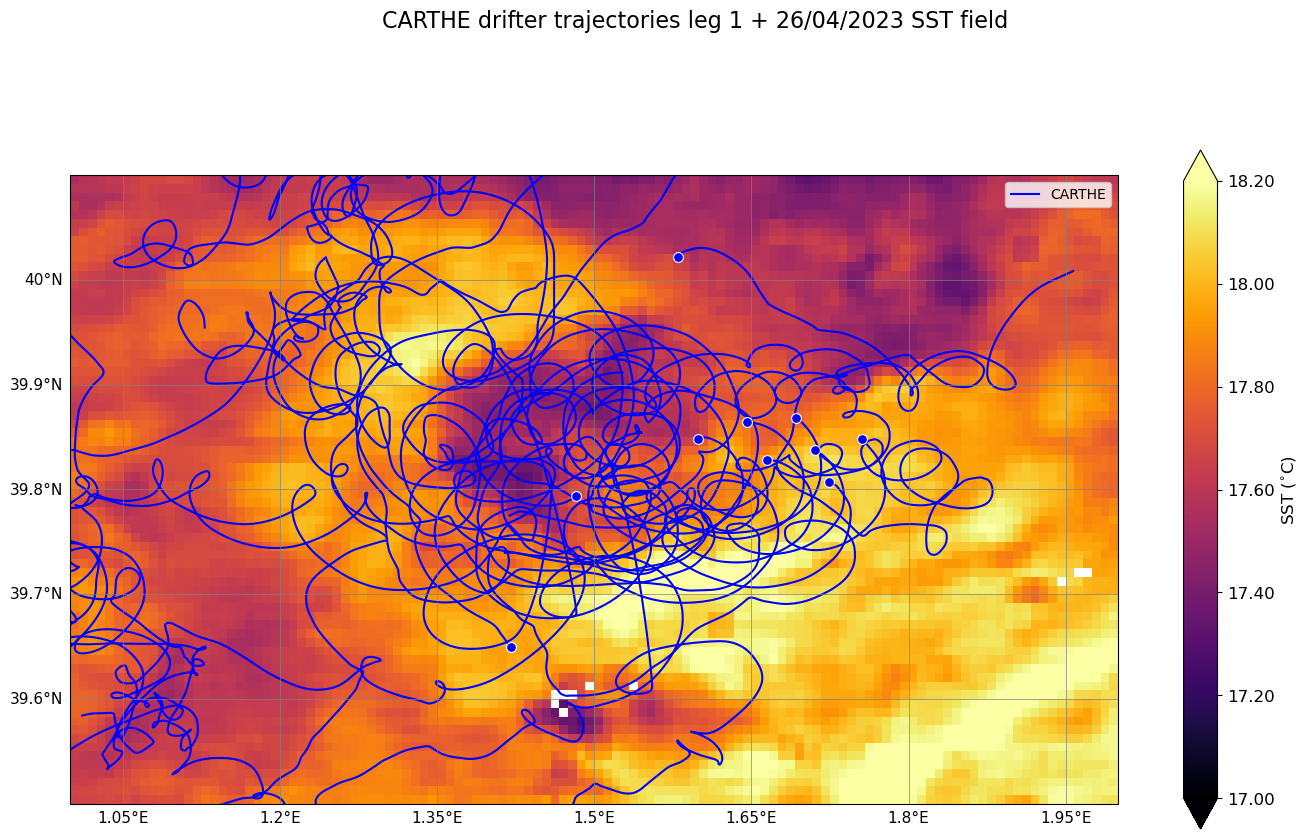

In [75]:
fsize = 12

plt.close()
plt.cla
plt.clf

fig = plt.figure(figsize=(14,10))
ax1  = plt.subplot(111, projection=ccrs.PlateCarree())
# Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                                   scale='10m', zorder=10,
#                                                   edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)

# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
#gl.left_labels = False
gl.right_labels = False
# if aan < ((gs_y * (gs_x-2)) - sub_uneq): # for horizontal cbar at bottom * (gs_x-1)):
#     gl.bottom_labels = False
# if ((aan == 0) | (aan % gs_y == 0)) & (aan < gs_y * (gs_x-1)):  # last and is only valid if colorbar in bottom row
#     gl.left_labels = True

gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}
  
##
for ii, ds in enumerate(ds_car_leg1):
    
    #cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=2)

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    if ii == 0:
        ax1.plot(ds.LON[6:-6], ds.LAT[6:-6], transform=ccrs.PlateCarree(), c='b', label='CARTHE')
    else:
        ax1.plot(ds.LON[6:-6], ds.LAT[6:-6], transform=ccrs.PlateCarree(), c='b')

    ax1.scatter(ds.LON[6], ds.LAT[6], s=50, c='b', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    
###

# fix, see chl notebook 13
field = (ds_sst.adjusted_sea_surface_temperature[0,:,:] - 273) # Ploting 15/05/23
# field = np.log10(ds_chl_230506.CHL.squeeze())
cmap = 'inferno' #cmocean.cm.thermal
#cbar_label = r'SST ($degrees$)'
vmin = 17.  #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
vmax = 18.2 ##np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
cc = ax1.pcolormesh(
    ds_sst.lon , ds_sst.lat, field,
    cmap = cmap,
    vmin = vmin,
    vmax = vmax,
    transform=ccrs.PlateCarree(),
    shading='auto',
    )

cbar = plt.colorbar(cc,
            #cax=axC,
            #orientation='horizontal',
            extend='both',
            shrink=0.7,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )

cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_ylabel(cbar_label, fontsize=12)

plt.xlim([1., 2.])
plt.ylim([39.5, 40.1])
plt.legend(loc=1)

plt.tight_layout()
plt.suptitle('CARTHE drifter trajectories leg 1 + 26/04/2023 SST field', size=16);

plt.savefig(savefigdir + 'CARTHE_proc_drifters_FullTraj_SST_260423_Leg1.png', dpi=300) 
plt.show()

# +/- 5 days:

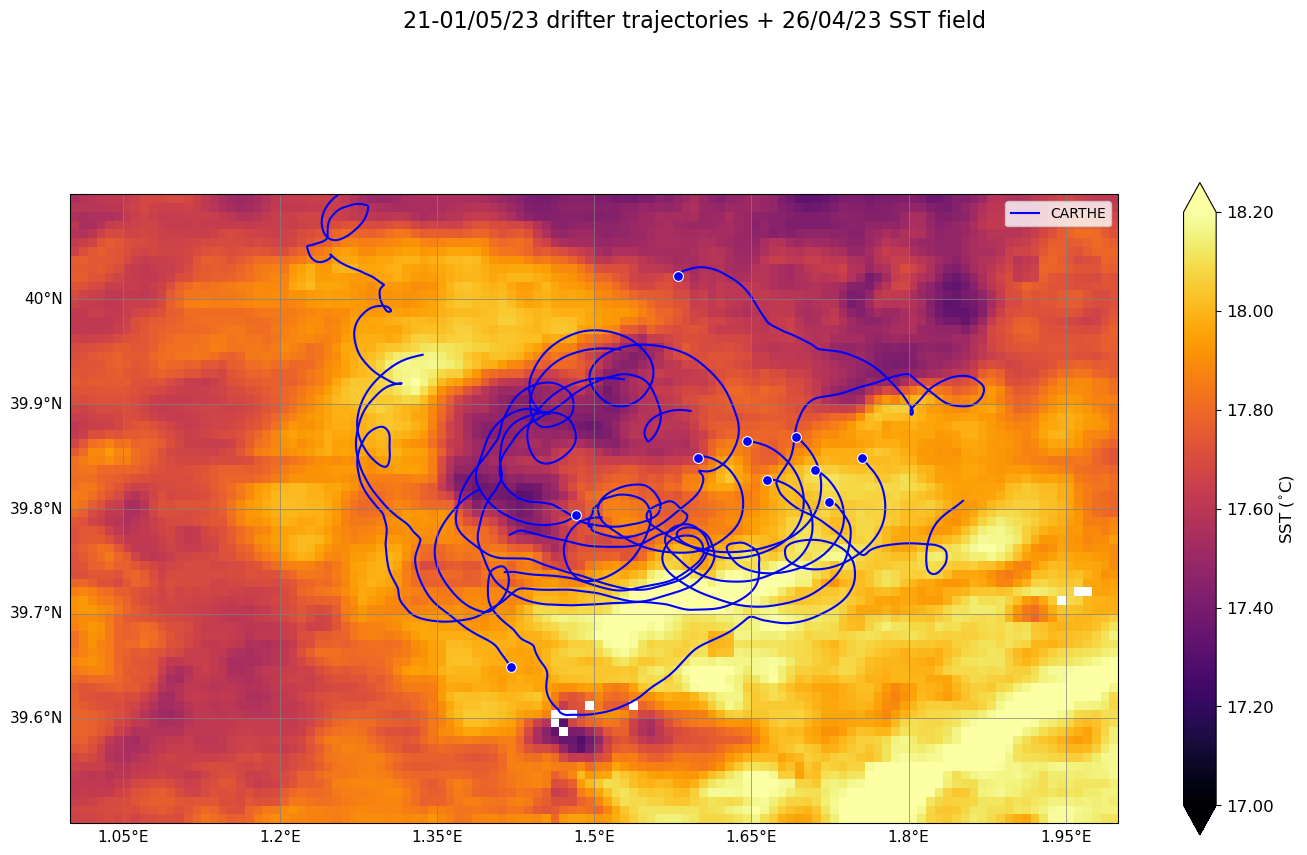

In [77]:
dd = 26
dd1 = str(dd-5).zfill(2)
dd2 = '01' #str(dd+5).zfill(2)

fsize = 12

plt.close()
plt.cla
plt.clf

fig = plt.figure(figsize=(14,10))
ax1  = plt.subplot(111, projection=ccrs.PlateCarree())
# Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                                   scale='10m', zorder=10,
#                                                   edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)

# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
#gl.left_labels = False
gl.right_labels = False
# if aan < ((gs_y * (gs_x-2)) - sub_uneq): # for horizontal cbar at bottom * (gs_x-1)):
#     gl.bottom_labels = False
# if ((aan == 0) | (aan % gs_y == 0)) & (aan < gs_y * (gs_x-1)):  # last and is only valid if colorbar in bottom row
#     gl.left_labels = True

gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}
  
##
for ii, ds in enumerate(ds_car_leg1):
    
    #cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=2)

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:

    ds_s = ds.sel(time=slice("2023-04-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        if ii == 0:
            ax1.plot(ds_s.LON[6:-6], ds_s.LAT[6:-6], transform=ccrs.PlateCarree(), c='b', label='CARTHE')
        else:
            ax1.plot(ds_s.LON[6:-6], ds_s.LAT[6:-6], transform=ccrs.PlateCarree(), c='b')

        ax1.scatter(ds.LON[6], ds.LAT[6], s=50, c='b', edgecolor='w', linewidths=0.8,
                    zorder=500, transform=ccrs.PlateCarree())

        
    
###

# fix, see chl notebook 13
field = (ds_sst.adjusted_sea_surface_temperature[0,:,:] - 273) # Ploting 15/05/23
# field = np.log10(ds_chl_230506.CHL.squeeze())
cmap = 'inferno' #cmocean.cm.thermal
#cbar_label = r'SST ($degrees$)'
vmin = 17.  #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
vmax = 18.2 ##np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
cc = ax1.pcolormesh(
    ds_sst.lon , ds_sst.lat, field,
    cmap = cmap,
    vmin = vmin,
    vmax = vmax,
    transform=ccrs.PlateCarree(),
    shading='auto',
    )

cbar = plt.colorbar(cc,
            #cax=axC,
            #orientation='horizontal',
            extend='both',
            shrink=0.7,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )

cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_ylabel(cbar_label, fontsize=12)

plt.xlim([1., 2.])
plt.ylim([39.5, 40.1])
plt.legend(loc=1)

plt.suptitle(dd1 + '-' + dd2 + '/05/23 drifter trajectories + 26/04/23 SST field', size=16);

# plt.savefig('CARTHE_proc_drifters_FullTraj_SST_260423_Leg1.png', dpi=300) 

plt.tight_layout()
# plt.suptitle('CARTHE drifter trajectories leg 1 + 26/04/2023 SST field', size=16);
plt.savefig(savefigdir + 'CARTHE_proc_drifters_5d_SST_260423_Leg1.png', dpi=300) 
plt.show()


<a id="2.2.4."></a> <br>
### 2.2.4. Only trajectory on day 15/05/23 (+/- 1 day):

<a id="2.3."></a> <br>
## 2.3. HEREON:

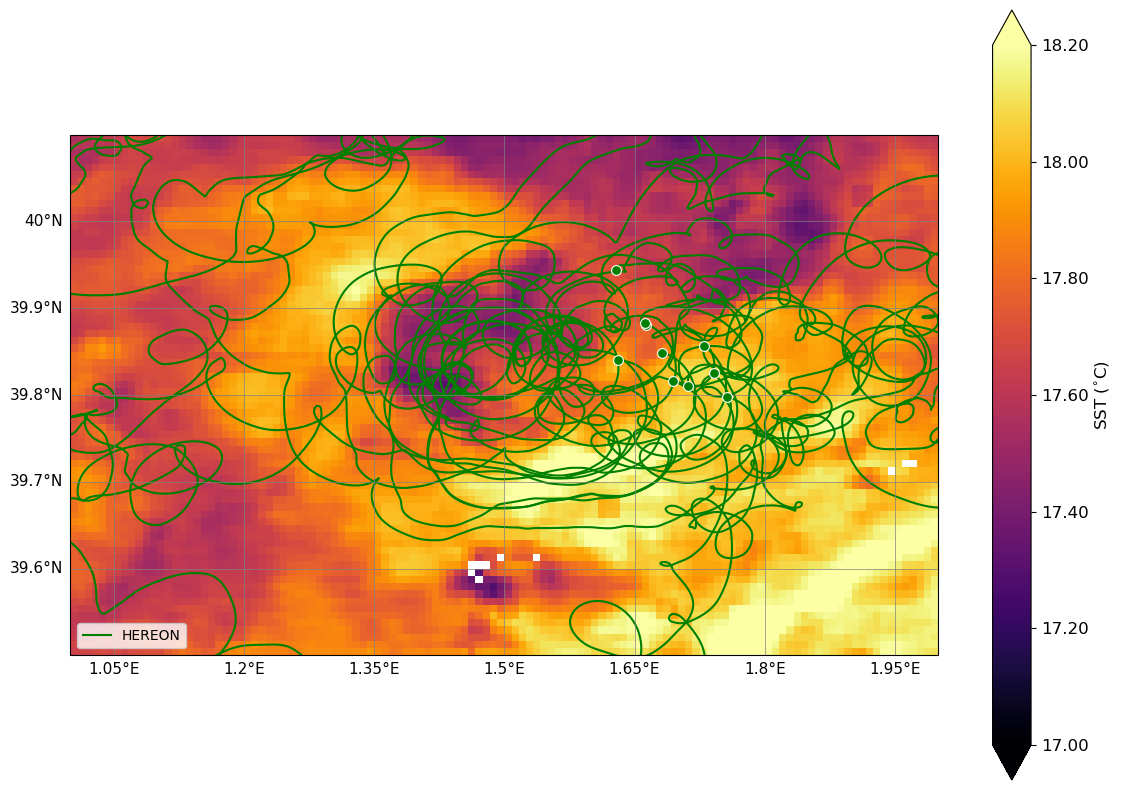

In [56]:
fsize = 12

plt.close()
plt.cla
plt.clf

fig = plt.figure(figsize=(14,10))
ax1  = plt.subplot(111, projection=ccrs.PlateCarree())
# Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                                   scale='10m', zorder=10,
#                                                   edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)

# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
#gl.left_labels = False
gl.right_labels = False
# if aan < ((gs_y * (gs_x-2)) - sub_uneq): # for horizontal cbar at bottom * (gs_x-1)):
#     gl.bottom_labels = False
# if ((aan == 0) | (aan % gs_y == 0)) & (aan < gs_y * (gs_x-1)):  # last and is only valid if colorbar in bottom row
#     gl.left_labels = True

gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}
  
##
for ii, ds in enumerate(ds_her_leg1):
    
    if ii == 0:
        ax1.plot(ds.LON[6:-6], ds.LAT[6:-6], transform=ccrs.PlateCarree(), c='g', label='HEREON')
    else:
        ax1.plot(ds.LON[6:-6], ds.LAT[6:-6], transform=ccrs.PlateCarree(), c='g')

    ax1.scatter(ds.LON[6], ds.LAT[6], s=50, c='g', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    
###

# fix, see chl notebook 13
field = (ds_sst.adjusted_sea_surface_temperature[0,:,:] - 273) # Ploting 15/05/23
# field = np.log10(ds_chl_230506.CHL.squeeze())
cmap = 'inferno' #cmocean.cm.thermal
#cbar_label = r'SST ($degrees$)'
vmin = 17.  #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
vmax = 18.2 ##np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
cc = ax1.pcolormesh(
    ds_sst.lon , ds_sst.lat, field,
    cmap = cmap,
    vmin = vmin,
    vmax = vmax,
    transform=ccrs.PlateCarree(),
    shading='auto',
    )

cbar = plt.colorbar(cc,
            #cax=axC,
            #orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )

cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_ylabel(cbar_label, fontsize=12)

plt.xlim([1., 2.])
plt.ylim([39.5, 40.1])
plt.legend()

# plt.tight_layout()
# plt.suptitle('Drifter trajectories + 26/04/2023 SST field', size=16);

# plt.savefig('CARTHE_proc_drifters_FullTraj_SST_260423_Leg1.png', dpi=300) 


# +/- 5 days:

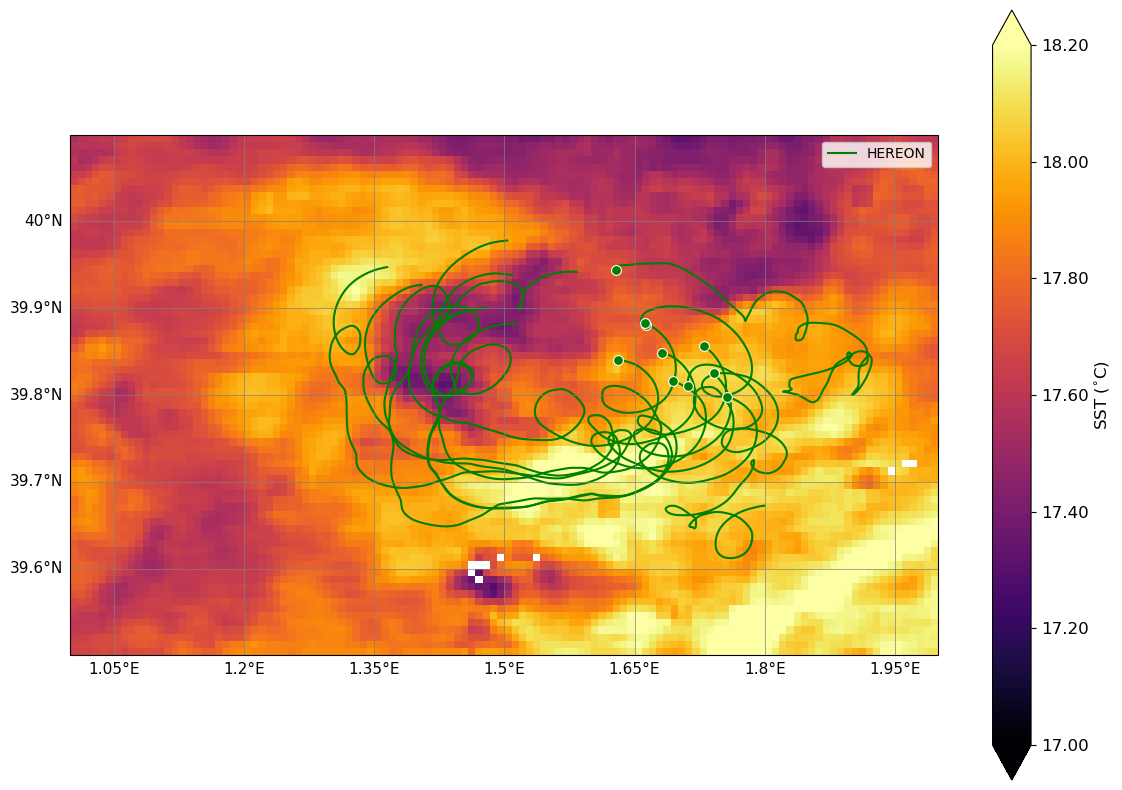

In [55]:

dd = 26
dd1 = str(dd-5).zfill(2)
dd2 = '01' #str(dd+5).zfill(2)

fsize = 12

plt.close()
plt.cla
plt.clf

fig = plt.figure(figsize=(14,10))
ax1  = plt.subplot(111, projection=ccrs.PlateCarree())
# Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                                   scale='10m', zorder=10,
#                                                   edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)

# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
#gl.left_labels = False
gl.right_labels = False
# if aan < ((gs_y * (gs_x-2)) - sub_uneq): # for horizontal cbar at bottom * (gs_x-1)):
#     gl.bottom_labels = False
# if ((aan == 0) | (aan % gs_y == 0)) & (aan < gs_y * (gs_x-1)):  # last and is only valid if colorbar in bottom row
#     gl.left_labels = True

gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}
  
##
for ii, ds in enumerate(ds_her_leg1):
    
    #cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=2)

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:

    ds_s = ds.sel(time=slice("2023-04-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        if ii == 0:
            ax1.plot(ds_s.LON[6:-6], ds_s.LAT[6:-6], transform=ccrs.PlateCarree(), c='g', label='HEREON')
        else:
            ax1.plot(ds_s.LON[6:-6], ds_s.LAT[6:-6], transform=ccrs.PlateCarree(), c='g')

        ax1.scatter(ds.LON[6], ds.LAT[6], s=50, c='g', edgecolor='w', linewidths=0.8,
                    zorder=500, transform=ccrs.PlateCarree())

        
    
###

# fix, see chl notebook 13
field = (ds_sst.adjusted_sea_surface_temperature[0,:,:] - 273) # Ploting 15/05/23
# field = np.log10(ds_chl_230506.CHL.squeeze())
cmap = 'inferno' #cmocean.cm.thermal
#cbar_label = r'SST ($degrees$)'
vmin = 17.  #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
vmax = 18.2 ##np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
cc = ax1.pcolormesh(
    ds_sst.lon , ds_sst.lat, field,
    cmap = cmap,
    vmin = vmin,
    vmax = vmax,
    transform=ccrs.PlateCarree(),
    shading='auto',
    )

cbar = plt.colorbar(cc,
            #cax=axC,
            #orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )

cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_ylabel(cbar_label, fontsize=12)

plt.xlim([1., 2.])
plt.ylim([39.5, 40.1])
plt.legend()

# plt.tight_layout()
# plt.suptitle('Drifter trajectories + 26/04/2023 SST field', size=16);
# plt.suptitle(dd1 + '-' + dd2 + '/05/23 drifter trajectories + 15/05/23 SST field', size=16);

# plt.savefig('CARTHE_proc_drifters_5d_SST_260423_Leg1.png', dpi=300) 




<a id="2.3.1."></a> <br>
# All

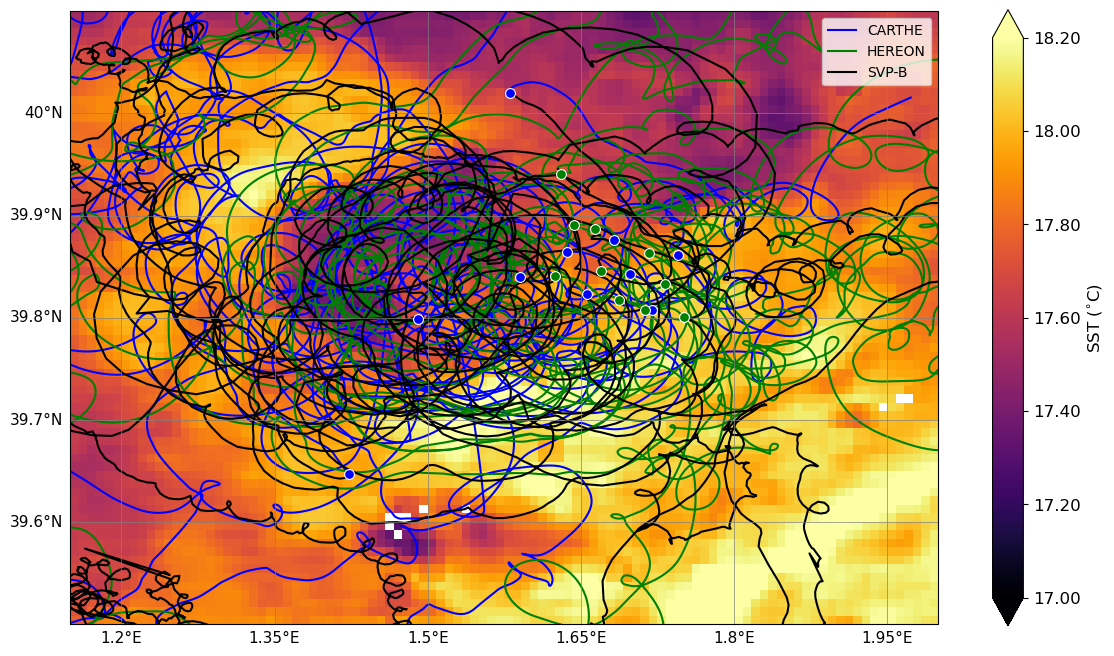

In [37]:
fsize = 12

plt.close()
plt.cla
plt.clf

fig = plt.figure(figsize=(14,10))
ax1  = plt.subplot(111, projection=ccrs.PlateCarree())
# Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                                   scale='10m', zorder=10,
#                                                   edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)

# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
#gl.left_labels = False
gl.right_labels = False
# if aan < ((gs_y * (gs_x-2)) - sub_uneq): # for horizontal cbar at bottom * (gs_x-1)):
#     gl.bottom_labels = False
# if ((aan == 0) | (aan % gs_y == 0)) & (aan < gs_y * (gs_x-1)):  # last and is only valid if colorbar in bottom row
#     gl.left_labels = True

gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}

for ii, ds in enumerate(ds_car_leg1):
    
    #cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=2)

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    if ii == 0:
        ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='b', label='CARTHE')
    else:
        ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='b')

    ax1.scatter(ds.LON[0], ds.LAT[0], s=50, c='b', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    
##
for ii, ds in enumerate(ds_her_leg1):
    
    if ii == 0:
        ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='g', label='HEREON')
    else:
        ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='g')

    ax1.scatter(ds.LON[0], ds.LAT[0], s=50, c='g', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
for ii, ds in enumerate(ds_svp_leg1):

    #ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    #cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True) 

    if ii == 0:
        ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='k', label='SVP-B') 
    else:
        ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='k') 
    ax1.scatter(ds.LON[0], ds.LAT[0], c='k', edgecolor='w', linewidths=0.8, transform=ccrs.PlateCarree())
        
###

# fix, see chl notebook 13
field = (ds_sst.adjusted_sea_surface_temperature[0,:,:] - 273) # Ploting 15/05/23
# field = np.log10(ds_chl_230506.CHL.squeeze())
cmap = 'inferno' #cmocean.cm.thermal
#cbar_label = r'SST ($degrees$)'
vmin = 17.  #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
vmax = 18.2 ##np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
cc = ax1.pcolormesh(
    ds_sst.lon , ds_sst.lat, field,
    cmap = cmap,
    vmin = vmin,
    vmax = vmax,
    transform=ccrs.PlateCarree(),
    shading='auto',
    )

cbar = plt.colorbar(cc,
            #cax=axC,
            #orientation='horizontal',
            extend='both',
            shrink=0.8,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )

cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_ylabel(cbar_label, fontsize=12)

plt.xlim([1.15, 2.])
plt.ylim([39.5, 40.1])
plt.legend(loc=1)

# plt.tight_layout()
# plt.suptitle('Drifter trajectories + 26/04/2023 SST field', size=16);

# plt.savefig('CARTHE_proc_drifters_FullTraj_SST_260423_Leg1.png', dpi=300) 


## +/- 5 days:

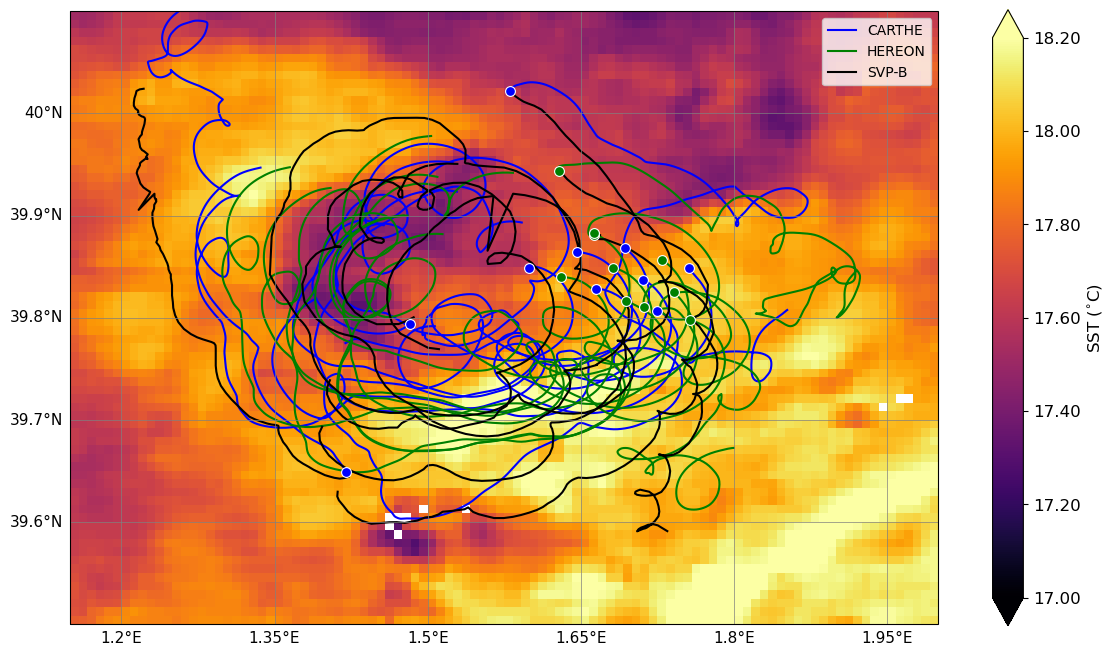

In [36]:

dd = 26
dd1 = str(dd-5).zfill(2)
dd2 = '01' #str(dd+5).zfill(2)

fsize = 12

plt.close()
plt.cla
plt.clf

fig = plt.figure(figsize=(14,10))
ax1  = plt.subplot(111, projection=ccrs.PlateCarree())
# Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                                   scale='10m', zorder=10,
#                                                   edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)

# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
#gl.left_labels = False
gl.right_labels = False
# if aan < ((gs_y * (gs_x-2)) - sub_uneq): # for horizontal cbar at bottom * (gs_x-1)):
#     gl.bottom_labels = False
# if ((aan == 0) | (aan % gs_y == 0)) & (aan < gs_y * (gs_x-1)):  # last and is only valid if colorbar in bottom row
#     gl.left_labels = True

gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}
  
##
for ii, ds in enumerate(ds_car_leg1):

    ds_s = ds.sel(time=slice("2023-04-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        if ii == 0:
            ax1.plot(ds_s.LON[6:-6], ds_s.LAT[6:-6], transform=ccrs.PlateCarree(), c='b', label='CARTHE')
        else:
            ax1.plot(ds_s.LON[6:-6], ds_s.LAT[6:-6], transform=ccrs.PlateCarree(), c='b')

        ax1.scatter(ds.LON[6], ds.LAT[6], s=50, c='b', edgecolor='w', linewidths=0.8,
                    zorder=500, transform=ccrs.PlateCarree())

        
 

for ii, ds in enumerate(ds_her_leg1):

    ds_s = ds.sel(time=slice("2023-04-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
    else:
        if ii == 0:
            ax1.plot(ds_s.LON[6:-6], ds_s.LAT[6:-6], transform=ccrs.PlateCarree(), c='g', label='HEREON')
        else:
            ax1.plot(ds_s.LON[6:-6], ds_s.LAT[6:-6], transform=ccrs.PlateCarree(), c='g')

        ax1.scatter(ds.LON[6], ds.LAT[6], s=50, c='g', edgecolor='w', linewidths=0.8,
                    zorder=500, transform=ccrs.PlateCarree())

        
for ii, ds in enumerate(ds_svp_leg1):

    ds_s = ds.sel(time=slice("2023-04-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')

    if ii == 0:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='k', label='SVP-B') 
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='k') 
    ax1.scatter(ds_s.LON[0], ds_s.LAT[0], c='k', edgecolor='w', linewidths=0.8, transform=ccrs.PlateCarree())
      
###

# fix, see chl notebook 13
field = (ds_sst.adjusted_sea_surface_temperature[0,:,:] - 273) # Ploting 15/05/23
# field = np.log10(ds_chl_230506.CHL.squeeze())
cmap = 'inferno' #cmocean.cm.thermal
#cbar_label = r'SST ($degrees$)'
vmin = 17.  #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
vmax = 18.2 ##np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
cc = ax1.pcolormesh(
    ds_sst.lon , ds_sst.lat, field,
    cmap = cmap,
    vmin = vmin,
    vmax = vmax,
    transform=ccrs.PlateCarree(),
    shading='auto',
    )

cbar = plt.colorbar(cc,
            #cax=axC,
            #orientation='horizontal',
            extend='both',
            shrink=0.8,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )

cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_ylabel(cbar_label, fontsize=12)

plt.xlim([1.15, 2.])
plt.ylim([39.5, 40.1])
plt.legend(loc=1)

# plt.tight_layout()
# plt.suptitle('Drifter trajectories + 26/04/2023 SST field', size=16);
# plt.suptitle(dd1 + '-' + dd2 + '/05/23 drifter trajectories + 15/05/23 SST field', size=16);

# plt.savefig('CARTHE_proc_drifters_FullTraj_SST_260423_Leg1.png', dpi=300) 




# Subplot:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No trajectory segment on these days


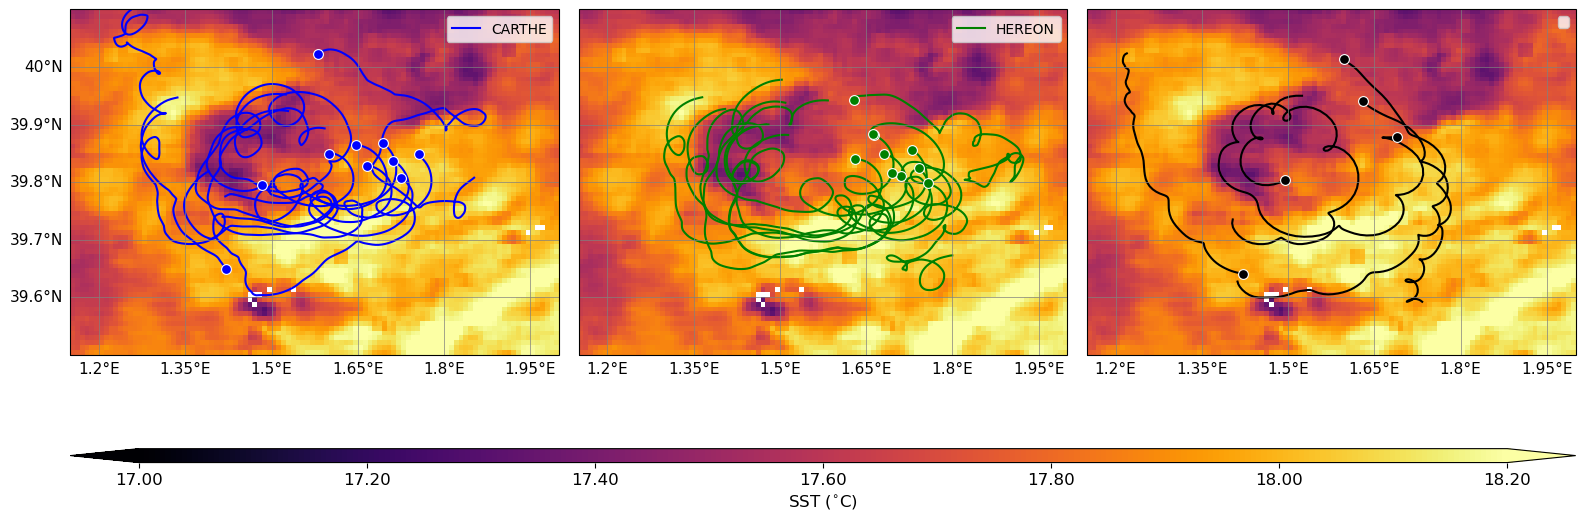

In [84]:

dd = 26
dd1 = str(dd-5).zfill(2)
dd2 = '01' #str(dd+5).zfill(2)

fsize = 12

plt.close()
plt.cla
plt.clf

fig = plt.figure(figsize=(16,7))

gs  = gridspec.GridSpec(2, 3, height_ratios=[.98, .02])
axC = plt.subplot(gs[-1,:])

#####
ax1  = plt.subplot(gs[0], projection=ccrs.PlateCarree())
# Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                                   scale='10m', zorder=10,
#                                                   edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)

# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
#gl.left_labels = False
gl.right_labels = False
# if aan < ((gs_y * (gs_x-2)) - sub_uneq): # for horizontal cbar at bottom * (gs_x-1)):
#     gl.bottom_labels = False
# if ((aan == 0) | (aan % gs_y == 0)) & (aan < gs_y * (gs_x-1)):  # last and is only valid if colorbar in bottom row
#     gl.left_labels = True

gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}
  
##
for ii, ds in enumerate(ds_car_leg1):

    ds_s = ds.sel(time=slice("2023-04-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        if ii == 0:
            ax1.plot(ds_s.LON[6:-6], ds_s.LAT[6:-6], transform=ccrs.PlateCarree(), c='b', label='CARTHE')
        else:
            ax1.plot(ds_s.LON[6:-6], ds_s.LAT[6:-6], transform=ccrs.PlateCarree(), c='b')

        ax1.scatter(ds.LON[6], ds.LAT[6], s=50, c='b', edgecolor='w', linewidths=0.8,
                    zorder=500, transform=ccrs.PlateCarree())

        
###

# fix, see chl notebook 13
field = (ds_sst.adjusted_sea_surface_temperature[0,:,:] - 273) # Ploting 15/05/23
# field = np.log10(ds_chl_230506.CHL.squeeze())
cmap = 'inferno' #cmocean.cm.thermal
#cbar_label = r'SST ($degrees$)'
vmin = 17.  #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
vmax = 18.2 ##np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
cc = ax1.pcolormesh(
    ds_sst.lon , ds_sst.lat, field,
    cmap = cmap,
    vmin = vmin,
    vmax = vmax,
    transform=ccrs.PlateCarree(),
    shading='auto',
    )


plt.xlim([1.15, 2.])
plt.ylim([39.5, 40.1])
plt.legend(loc=1)

#########
#####
ax1  = plt.subplot(gs[1], projection=ccrs.PlateCarree())
# Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                                   scale='10m', zorder=10,
#                                                   edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)

# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.left_labels = False
gl.right_labels = False
# if aan < ((gs_y * (gs_x-2)) - sub_uneq): # for horizontal cbar at bottom * (gs_x-1)):
#     gl.bottom_labels = False
# if ((aan == 0) | (aan % gs_y == 0)) & (aan < gs_y * (gs_x-1)):  # last and is only valid if colorbar in bottom row
#     gl.left_labels = True

gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}
  
##


for ii, ds in enumerate(ds_her_leg1):

    ds_s = ds.sel(time=slice("2023-04-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
    else:
        if ii == 0:
            ax1.plot(ds_s.LON[6:-6], ds_s.LAT[6:-6], transform=ccrs.PlateCarree(), c='g', label='HEREON')
        else:
            ax1.plot(ds_s.LON[6:-6], ds_s.LAT[6:-6], transform=ccrs.PlateCarree(), c='g')

        ax1.scatter(ds.LON[6], ds.LAT[6], s=50, c='g', edgecolor='w', linewidths=0.8,
                    zorder=500, transform=ccrs.PlateCarree())

        

###

# fix, see chl notebook 13
field = (ds_sst.adjusted_sea_surface_temperature[0,:,:] - 273) # Ploting 15/05/23
# field = np.log10(ds_chl_230506.CHL.squeeze())
cmap = 'inferno' #cmocean.cm.thermal
#cbar_label = r'SST ($degrees$)'
vmin = 17.  #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
vmax = 18.2 ##np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
cc = ax1.pcolormesh(
    ds_sst.lon , ds_sst.lat, field,
    cmap = cmap,
    vmin = vmin,
    vmax = vmax,
    transform=ccrs.PlateCarree(),
    shading='auto',
    )

plt.xlim([1.15, 2.])
plt.ylim([39.5, 40.1])
plt.legend(loc=1)
########
########
ax1  = plt.subplot(gs[2], projection=ccrs.PlateCarree())

# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.left_labels = False
gl.right_labels = False
# if aan < ((gs_y * (gs_x-2)) - sub_uneq): # for horizontal cbar at bottom * (gs_x-1)):
#     gl.bottom_labels = False
# if ((aan == 0) | (aan % gs_y == 0)) & (aan < gs_y * (gs_x-1)):  # last and is only valid if colorbar in bottom row
#     gl.left_labels = True

gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}

        
for ii, ds in enumerate(ds_svp_leg1):

    ds_s = ds.sel(time=slice("2023-04-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
    else:
        if ii == 0:
            ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='k', label='SVP-B') 
        else:
            ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='k') 
        ax1.scatter(ds_s.LON[0].values, ds_s.LAT[0].values, s=50, c='k', edgecolor='w',
                    zorder=500, linewidths=0.8, transform=ccrs.PlateCarree())
 
###

# fix, see chl notebook 13
field = (ds_sst.adjusted_sea_surface_temperature[0,:,:] - 273) # Ploting 15/05/23
# field = np.log10(ds_chl_230506.CHL.squeeze())
cmap = 'inferno' #cmocean.cm.thermal
#cbar_label = r'SST ($degrees$)'
vmin = 17.  #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
vmax = 18.2 ##np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
cc = ax1.pcolormesh(
    ds_sst.lon , ds_sst.lat, field,
    cmap = cmap,
    vmin = vmin,
    vmax = vmax,
    transform=ccrs.PlateCarree(),
    shading='auto',
    )

cbar = plt.colorbar(cc,
            cax=axC,
            orientation='horizontal',
            extend='both',
            shrink=0.8,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )

cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

plt.xlim([1.15, 2.])
plt.ylim([39.5, 40.1])
plt.legend(loc=1)
##########

plt.tight_layout()
plt.savefig(savefigdir + 'ALL_proc_drifters_5d_SST_260423_Leg1_subplot.png', dpi=300) 
plt.show()